# Solaqua_fish

This is the code for getting the images and labels for solaqua fish dataset

In [1]:
from pathlib import Path
import zipfile

base_dir = Path.cwd()
zip_path = base_dir / "SOLAQUAFISH_label_studio_images_and_labels.zip"
extract_dir = base_dir / "processed"
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print(f"Extracted {zip_path.name} into {extract_dir}")

Extracted SOLAQUAFISH_label_studio_images_and_labels.zip into /cluster/home/henrban/aquaculture-perception/data-processing/vision/solaqua_fish/processed


In [1]:
# what do we have?
from pathlib import Path
from collections import Counter
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
data_dir = Path.cwd() / "processed"
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

# -----------------------------
# HELPERS
# -----------------------------
def find_label_file(img_path: Path, root: Path):
    """
    Try to find the YOLO label file for an image.
    Supports common layouts like:
      processed/images/train/a.jpg  -> processed/labels/train/a.txt
      processed/train/images/a.jpg  -> processed/train/labels/a.txt
      processed/a.jpg               -> processed/a.txt
    """
    candidates = []

    # 1) same folder, same stem
    candidates.append(img_path.with_suffix(".txt"))

    # 2) replace any 'images' folder in path with 'labels'
    rel = img_path.relative_to(root)
    parts = list(rel.parts)
    for i, part in enumerate(parts):
        if part.lower() == "images":
            new_parts = parts.copy()
            new_parts[i] = "labels"
            candidates.append((root / Path(*new_parts)).with_suffix(".txt"))

    # remove duplicates while keeping order
    seen = set()
    deduped = []
    for c in candidates:
        if c not in seen:
            seen.add(c)
            deduped.append(c)

    for c in deduped:
        if c.exists():
            return c

    return None


def count_instances_in_label(label_path: Path):
    """
    Count YOLO instances = number of non-empty lines.
    Also return per-class counts from the first token on each line.
    """
    if label_path is None or not label_path.exists():
        return 0, Counter()

    class_counts = Counter()
    instance_count = 0

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            instance_count += 1
            class_id = line.split()[0]
            class_counts[class_id] += 1

    return instance_count, class_counts


# -----------------------------
# COLLECT IMAGES
# -----------------------------
images = sorted([p for p in data_dir.rglob("*") if p.suffix.lower() in image_exts])

if not images:
    raise FileNotFoundError(f"No images found under {data_dir}")

rows = []
total_class_counts = Counter()
label_files_found = 0

for img_path in images:
    label_path = find_label_file(img_path, data_dir)
    has_label_file = label_path is not None

    if has_label_file:
        label_files_found += 1

    instance_count, class_counts = count_instances_in_label(label_path)
    total_class_counts.update(class_counts)

    is_background = instance_count == 0

    rows.append({
        "image_path": str(img_path.relative_to(data_dir)),
        "image_name": img_path.name,
        "label_path": str(label_path.relative_to(data_dir)) if label_path else None,
        "has_label_file": has_label_file,
        "instances": instance_count,
        "is_background": is_background,
    })

df = pd.DataFrame(rows).sort_values(["instances", "image_name"], ascending=[False, True]).reset_index(drop=True)

# -----------------------------
# SUMMARY
# -----------------------------
total_images = len(df)
images_with_label_file = int(df["has_label_file"].sum())
images_with_instances = int((df["instances"] > 0).sum())
background_images = int(df["is_background"].sum())
total_instances = int(df["instances"].sum())

print("DATASET SUMMARY")
print("-" * 50)
print(f"Total images:                 {total_images}")
print(f"Images with label file:       {images_with_label_file}")
print(f"Images with >=1 instance:     {images_with_instances}")
print(f"Background images:            {background_images}")
print(f"Total annotation instances:   {total_instances}")

print("\nINSTANCES PER IMAGE")
print("-" * 50)
print(df[["image_name", "instances", "has_label_file", "is_background"]].to_string(index=False))

print("\nCLASS COUNTS (class_id -> instances)")
print("-" * 50)
if total_class_counts:
    for class_id, count in sorted(total_class_counts.items(), key=lambda x: int(x[0]) if str(x[0]).isdigit() else str(x[0])):
        print(f"{class_id}: {count}")
else:
    print("No labeled instances found.")

# Optional: save detailed report
report_path = data_dir / "dataset_report.csv"
df.to_csv(report_path, index=False)
print(f"\nSaved detailed report to: {report_path}")

DATASET SUMMARY
--------------------------------------------------
Total images:                 793
Images with label file:       793
Images with >=1 instance:     734
Background images:            59
Total annotation instances:   3153

INSTANCES PER IMAGE
--------------------------------------------------
                            image_name  instances  has_label_file  is_background
64c66cd9-bag11_1724165170620087300.jpg         28            True          False
 358b01da-bag4_1724157153661738700.jpg         24            True          False
 f1427f9a-bag4_1724157153491078100.jpg         24            True          False
 0df8bd9a-bag4_1724157152211978200.jpg         23            True          False
 25546a1f-bag4_1724157152531125900.jpg         23            True          False
 5abb59d3-bag4_1724157152381346900.jpg         22            True          False
 6f87aeb4-bag4_1724157154134921700.jpg         22            True          False
 3ae97ad4-bag4_1724157153812822000.jpg     

### make split

This code creates a bag-disjoint train/validation/test split for the YOLO dataset. Its purpose is to ensure that all images originating from the same bag are placed in only one split, which prevents leakage between training and evaluation data. This is important because frames extracted from the same bag are highly correlated and would otherwise make the model performance appear artificially better. The script also tries to balance the splits with respect to the number of images, background images, positive images, and total fish instances, and then writes the resulting YOLO folder structure and dataset configuration files.

In [2]:
from pathlib import Path
import itertools
import math
import re
import shutil
from collections import defaultdict
import pandas as pd

# =========================================================
# CONFIG
# =========================================================
ROOT = Path.cwd() / "processed"
IMAGES_DIR = ROOT / "images"
LABELS_DIR = ROOT / "labels"
OUT_DIR = ROOT / "split_yolo"

# A bit more test data than 70/15/15:
TARGET_RATIOS = {
    "train": 0.65,
    "val":   0.15,
    "test":  0.20,
}

# Minimum number of bags per split
MIN_BAGS = {
    "train": 3,
    "val": 2,
    "test": 2,
}

# If True, deletes OUT_DIR before writing the new split
CLEAR_OUTPUT_DIR = True

# If True, actually copies files. If False, only computes and prints the split.
WRITE_FILES = True

# For dataset.yaml
CLASS_NAMES = ["fish"]   # edit if you have more classes

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

# Weights for how strongly the optimizer tries to match each distribution
METRIC_WEIGHTS = {
    "images": 1.0,
    "positive_images": 1.0,
    "background_images": 1.0,
    "instances_total": 1.0,
}

# =========================================================
# HELPERS
# =========================================================
def extract_bag_id(filename_stem: str) -> str:
    """
    Extract bag id from names like:
      7adee052-bag14_1724166882647838100
      bag15_1724169387559191900
    """
    m = re.search(r"(bag\d+)_", filename_stem)
    if not m:
        raise ValueError(f"Could not parse bag_id from filename stem: {filename_stem}")
    return m.group(1)


def get_label_path_for_image(img_path: Path) -> Path:
    """
    Supports both:
      processed/images/foo.jpg -> processed/labels/foo.txt
    and mirrored subfolders:
      processed/images/train/foo.jpg -> processed/labels/train/foo.txt
    """
    rel = img_path.relative_to(IMAGES_DIR)

    candidate_1 = (LABELS_DIR / rel).with_suffix(".txt")
    if candidate_1.exists():
        return candidate_1

    candidate_2 = LABELS_DIR / f"{img_path.stem}.txt"
    return candidate_2


def count_instances(label_path: Path) -> int:
    """
    YOLO instance count = number of non-empty lines in the txt file.
    Missing label file is treated as background (0 instances).
    """
    if not label_path.exists():
        return 0

    count = 0
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                count += 1
    return count


def choose_bag_counts(n_bags: int, ratios: dict, min_bags: dict) -> dict:
    """
    Choose number of bags per split.
    We bias test slightly upward by using ceil() for test.
    """
    n_test = max(min_bags["test"], math.ceil(ratios["test"] * n_bags))
    n_val = max(min_bags["val"], round(ratios["val"] * n_bags))
    n_train = n_bags - n_test - n_val

    while n_train < min_bags["train"]:
        # reduce the split that exceeds its target the most
        excess_test = n_test - ratios["test"] * n_bags
        excess_val = n_val - ratios["val"] * n_bags

        if n_test > min_bags["test"] and excess_test >= excess_val:
            n_test -= 1
        elif n_val > min_bags["val"]:
            n_val -= 1
        else:
            raise ValueError(
                f"Not enough bags ({n_bags}) for requested min split sizes {min_bags}"
            )
        n_train = n_bags - n_test - n_val

    return {"train": n_train, "val": n_val, "test": n_test}


def build_split_sums(split_bags: dict, bag_stats: dict) -> dict:
    out = {}
    for split, bags in split_bags.items():
        sums = defaultdict(int)
        for bag in bags:
            for metric, value in bag_stats[bag].items():
                sums[metric] += int(value)
        out[split] = dict(sums)
    return out


def score_split(split_sums: dict, totals: dict, target_ratios: dict, metric_weights: dict) -> float:
    """
    Lower is better.
    Penalizes deviation from target proportions for:
      - number of images
      - number of positive images
      - number of background images
      - total number of instances
    """
    score = 0.0

    for metric, weight in metric_weights.items():
        total_metric = totals[metric]
        if total_metric == 0:
            continue

        for split in ("train", "val", "test"):
            actual_ratio = split_sums[split].get(metric, 0) / total_metric
            target_ratio = target_ratios[split]
            score += weight * (actual_ratio - target_ratio) ** 2

    # Hard penalties if val/test accidentally become degenerate
    for split in ("val", "test"):
        if split_sums[split].get("images", 0) == 0:
            score += 1e6
        if split_sums[split].get("positive_images", 0) == 0:
            score += 1e6

    return score


# =========================================================
# LOAD DATASET
# =========================================================
image_paths = sorted(
    p for p in IMAGES_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
)

if not image_paths:
    raise FileNotFoundError(f"No images found in {IMAGES_DIR}")

records = []

for img_path in image_paths:
    bag_id = extract_bag_id(img_path.stem)
    label_path = get_label_path_for_image(img_path)
    instances = count_instances(label_path)
    has_label_file = label_path.exists()
    is_background = (instances == 0)

    records.append({
        "image_path": img_path,
        "label_path": label_path,
        "image_name": img_path.name,
        "label_name": label_path.name,
        "bag_id": bag_id,
        "instances": instances,
        "has_label_file": has_label_file,
        "is_background": is_background,
    })

df = pd.DataFrame(records)

print("Loaded dataset")
print(f"  Images: {len(df)}")
print(f"  Bags:   {df['bag_id'].nunique()}")

# =========================================================
# BAG-LEVEL SUMMARY
# =========================================================
bag_summary = (
    df.groupby("bag_id")
      .agg(
          images=("image_name", "size"),
          positive_images=("instances", lambda s: int((s > 0).sum())),
          background_images=("instances", lambda s: int((s == 0).sum())),
          instances_total=("instances", "sum"),
      )
      .reset_index()
      .sort_values("bag_id")
      .reset_index(drop=True)
)

bag_summary["background_rate"] = bag_summary["background_images"] / bag_summary["images"]
bag_summary["mean_instances_per_image"] = bag_summary["instances_total"] / bag_summary["images"]

print("\nBag summary:")
display(bag_summary)

bag_ids = bag_summary["bag_id"].tolist()
n_bags = len(bag_ids)

bag_counts = choose_bag_counts(n_bags, TARGET_RATIOS, MIN_BAGS)
print("\nChosen number of bags per split:")
print(bag_counts)

bag_stats = (
    bag_summary.set_index("bag_id")[["images", "positive_images", "background_images", "instances_total"]]
    .to_dict(orient="index")
)

totals = {
    "images": int(bag_summary["images"].sum()),
    "positive_images": int(bag_summary["positive_images"].sum()),
    "background_images": int(bag_summary["background_images"].sum()),
    "instances_total": int(bag_summary["instances_total"].sum()),
}

# =========================================================
# EXHAUSTIVE SEARCH OVER BAG ASSIGNMENTS
# =========================================================
best = None

all_bags = tuple(bag_ids)
n_test = bag_counts["test"]
n_val = bag_counts["val"]

for test_bags in itertools.combinations(all_bags, n_test):
    remaining_after_test = tuple(b for b in all_bags if b not in test_bags)

    for val_bags in itertools.combinations(remaining_after_test, n_val):
        train_bags = tuple(b for b in remaining_after_test if b not in val_bags)

        split_bags = {
            "train": train_bags,
            "val": val_bags,
            "test": test_bags,
        }

        split_sums = build_split_sums(split_bags, bag_stats)
        score = score_split(split_sums, totals, TARGET_RATIOS, METRIC_WEIGHTS)

        if best is None or score < best["score"]:
            best = {
                "score": score,
                "split_bags": split_bags,
                "split_sums": split_sums,
            }

if best is None:
    raise RuntimeError("Failed to find a valid bag split.")

bag_to_split = {}
for split, bags in best["split_bags"].items():
    for bag in bags:
        bag_to_split[bag] = split

print("\nBest bag assignment:")
for split in ("train", "val", "test"):
    print(f"  {split}: {list(best['split_bags'][split])}")

# =========================================================
# ASSIGN EACH IMAGE TO SPLIT
# =========================================================
df["split"] = df["bag_id"].map(bag_to_split)

split_summary = (
    df.groupby("split")
      .agg(
          bags=("bag_id", lambda s: s.nunique()),
          images=("image_name", "size"),
          positive_images=("instances", lambda s: int((s > 0).sum())),
          background_images=("instances", lambda s: int((s == 0).sum())),
          instances_total=("instances", "sum"),
      )
      .reindex(["train", "val", "test"])
      .reset_index()
)

split_summary["image_ratio"] = split_summary["images"] / len(df)
split_summary["background_rate"] = split_summary["background_images"] / split_summary["images"]
split_summary["mean_instances_per_image"] = split_summary["instances_total"] / split_summary["images"]

print("\nSplit summary:")
display(split_summary)

bag_assignment_df = bag_summary.copy()
bag_assignment_df["split"] = bag_assignment_df["bag_id"].map(bag_to_split)
bag_assignment_df = bag_assignment_df.sort_values(["split", "bag_id"]).reset_index(drop=True)

print("\nBag assignment table:")
display(bag_assignment_df)

# =========================================================
# WRITE FILES
# =========================================================
if WRITE_FILES:
    if CLEAR_OUTPUT_DIR and OUT_DIR.exists():
        shutil.rmtree(OUT_DIR)

    for split in ("train", "val", "test"):
        (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    for row in df.itertuples(index=False):
        split = row.split

        dst_img = OUT_DIR / "images" / split / row.image_name
        shutil.copy2(row.image_path, dst_img)

        dst_lbl = OUT_DIR / "labels" / split / f"{Path(row.image_name).stem}.txt"
        if Path(row.label_path).exists():
            shutil.copy2(row.label_path, dst_lbl)
        else:
            # background image without label file -> create empty YOLO txt
            dst_lbl.write_text("", encoding="utf-8")

    # Save reports
    save_df = df.copy()
    save_df["image_path"] = save_df["image_path"].astype(str)
    save_df["label_path"] = save_df["label_path"].astype(str)

    save_df.to_csv(OUT_DIR / "split_manifest.csv", index=False)
    bag_assignment_df.to_csv(OUT_DIR / "bag_assignment_summary.csv", index=False)
    split_summary.to_csv(OUT_DIR / "split_summary.csv", index=False)

    # Write YOLO dataset.yaml
    yaml_lines = [
        f"path: {OUT_DIR.as_posix()}",
        "train: images/train",
        "val: images/val",
        "test: images/test",
        "",
        "names:",
    ]
    for i, name in enumerate(CLASS_NAMES):
        yaml_lines.append(f"  {i}: {name}")

    (OUT_DIR / "dataset.yaml").write_text("\n".join(yaml_lines), encoding="utf-8")

    print(f"\nWrote split to: {OUT_DIR}")
    print(f"Dataset YAML:   {OUT_DIR / 'dataset.yaml'}")
    print(f"Manifest CSV:   {OUT_DIR / 'split_manifest.csv'}")
else:
    print("\nWRITE_FILES=False, so no files were copied.")

Loaded dataset
  Images: 793
  Bags:   12

Bag summary:


,bag_id,images,positive_images,background_images,instances_total,background_rate,mean_instances_per_image
0,bag1,72,71,1,222,0.013889,3.083333
1,bag10,48,43,5,219,0.104167,4.562500
2,bag11,35,34,1,159,0.028571,4.542857
3,bag12,90,79,11,292,0.122222,3.244444
4,bag13,73,69,4,344,0.054795,4.712329
5,bag14,147,134,13,201,0.088435,1.367347
6,bag15,110,102,8,399,0.072727,3.627273
7,bag2,76,71,5,246,0.065789,3.236842
8,bag3,19,17,2,29,0.105263,1.526316
9,bag4,75,75,0,955,0.000000,12.733333



Chosen number of bags per split:
{'train': 7, 'val': 2, 'test': 3}

Best bag assignment:
  train: ['bag1', 'bag12', 'bag13', 'bag14', 'bag4', 'bag8', 'bag9']
  val: ['bag10', 'bag2']
  test: ['bag11', 'bag15', 'bag3']

Split summary:


,split,bags,images,positive_images,background_images,instances_total,image_ratio,background_rate,mean_instances_per_image
0,train,7,505,467,38,2101,0.636822,0.075248,4.160396
1,val,2,124,114,10,465,0.156368,0.080645,3.750000
2,test,3,164,153,11,587,0.206810,0.067073,3.579268



Bag assignment table:


,bag_id,images,positive_images,background_images,instances_total,background_rate,mean_instances_per_image,split
0,bag11,35,34,1,159,0.028571,4.542857,test
1,bag15,110,102,8,399,0.072727,3.627273,test
2,bag3,19,17,2,29,0.105263,1.526316,test
3,bag1,72,71,1,222,0.013889,3.083333,train
4,bag12,90,79,11,292,0.122222,3.244444,train
5,bag13,73,69,4,344,0.054795,4.712329,train
6,bag14,147,134,13,201,0.088435,1.367347,train
7,bag4,75,75,0,955,0.000000,12.733333,train
8,bag8,32,23,9,25,0.281250,0.781250,train
9,bag9,16,16,0,62,0.000000,3.875000,train



Wrote split to: /cluster/home/henrban/aquaculture-perception/data-processing/vision/solaqua_fish/processed/split_yolo
Dataset YAML:   /cluster/home/henrban/aquaculture-perception/data-processing/vision/solaqua_fish/processed/split_yolo/dataset.yaml
Manifest CSV:   /cluster/home/henrban/aquaculture-perception/data-processing/vision/solaqua_fish/processed/split_yolo/split_manifest.csv


In [3]:
# Write yaml
from pathlib import Path


ROOT = Path.cwd()             

DATA = ROOT / "processed" 
IMAGES_TRAIN = DATA / "images" / "train"
IMAGES_VAL = DATA / "images" / "val"
IMAGES_TEST   = DATA / "images" / "test"        # or use a dedicated val split if you have one

dataset_yaml = f"""
train: {IMAGES_TRAIN.as_posix()}
val:   {IMAGES_VAL.as_posix()}
test:  {IMAGES_TEST.as_posix()}

# RUOD has 10 classes
names:
  - fish
"""
(ROOT / "solaqua_fish.yaml").write_text(dataset_yaml)
print("Wrote:", ROOT / "solaqua_fish.yaml")


Wrote: /cluster/home/henrban/aquaculture-perception/data-processing/vision/solaqua_fish/solaqua_fish.yaml


## Dataset summary:

In [1]:
from pathlib import Path
import sys

DATA_PROCESSING_ROOT = Path.cwd().resolve().parents[1]  # your working solution
sys.path.insert(0, str(DATA_PROCESSING_ROOT))

from utils.yolo_dataset_summary import count_from_yaml

counts = count_from_yaml("solaqua_fish.yaml")
# print(counts)
for split in ["train", "val", "test", "total"]:
    if split in counts:
        print(f"{split:5s}  images={counts[split]['images']:6d}  instances={counts[split]['instances']:8d}")


train  images=   505  instances=    2101
val    images=   124  instances=     465
test   images=   164  instances=     587
total  images=   793  instances=    3153


## Dataset examples

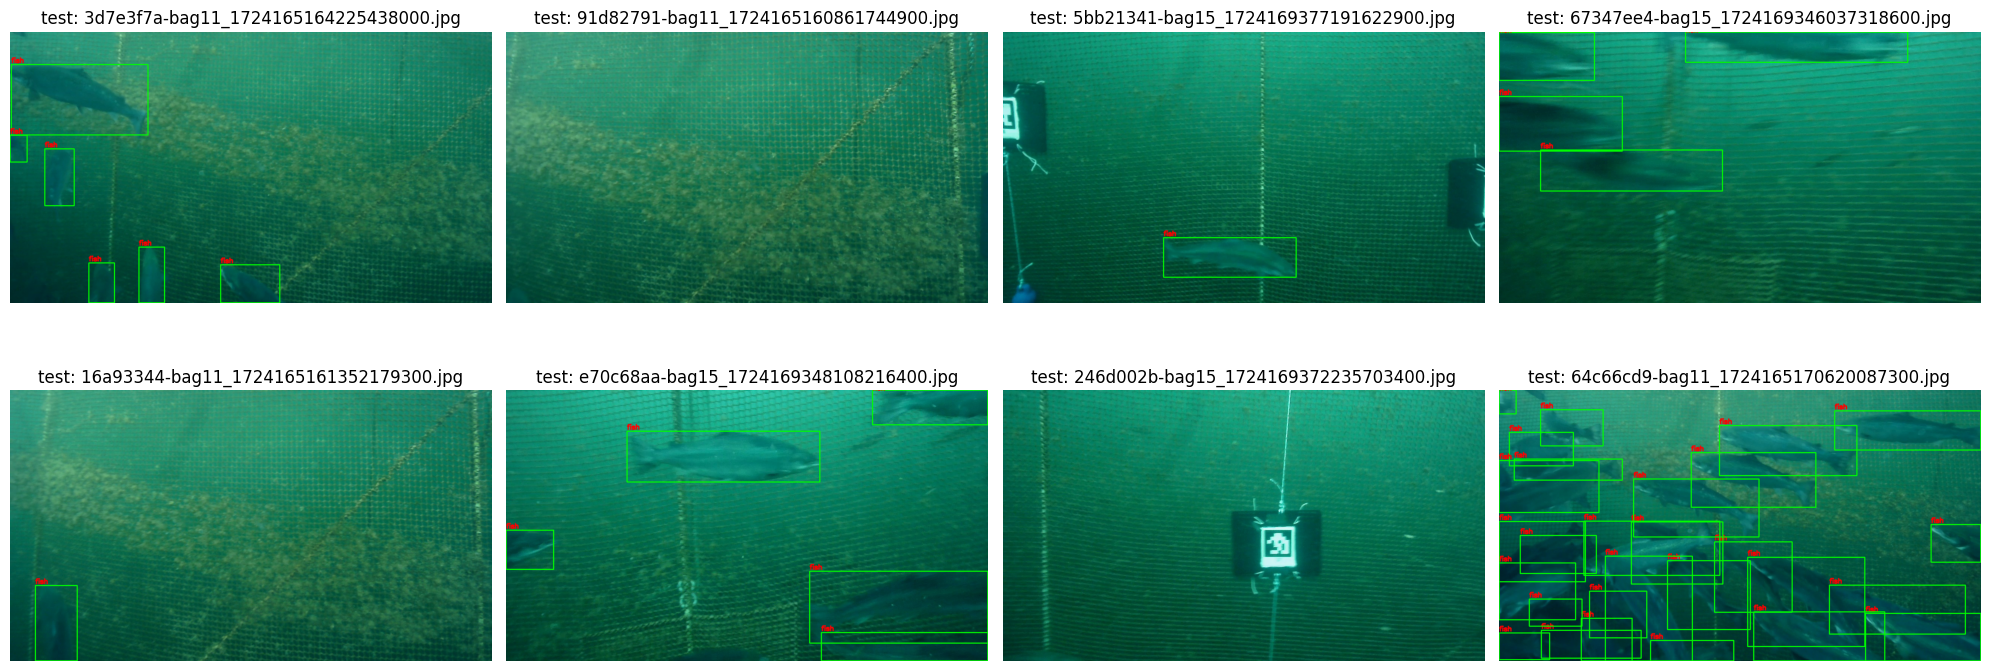

In [4]:
from pathlib import Path
import sys

DATA_PROCESSING_ROOT = Path.cwd().resolve().parents[1]  # RUOD -> vision -> data-processing
sys.path.insert(0, str(DATA_PROCESSING_ROOT))


from utils.yolo_viz import load_yolo_dataset_yaml, show_random_labeled_images

ds = load_yolo_dataset_yaml("solaqua_fish.yaml")  # yaml is next to the notebook

split = "test"  # train / val / test
img_dir = {"train": ds.train, "val": ds.val, "test": ds.test}[split]

show_random_labeled_images(
    images_split_dir=img_dir,
    names=ds.names,
    num_pics=8,
    cols=4,
    require_labels=True,
    
    title_prefix=f"{split}: ",
)
